# Лабораторная 1: GRU seq2seq с Luong attention для reverse-sequence

**Навигация:** Блок `02-Attention` · `ЛР01` · Шаг 4 курса

## Цель
Реализовать `GRU` encoder-decoder с `Luong attention`, который разворачивает входную последовательность в обратном порядке.

Эта лабораторная продолжает `01-RNN / ЛР03`, но убирает fixed-context bottleneck: decoder теперь может смотреть на все позиции `encoder_outputs`, а не только на один финальный вектор состояния.


## Что нужно знать до старта

Вы сейчас здесь: `02-Attention / ЛР01` — локальная ЛР01 блока `Attention`, Шаг 4 курса.
Предыдущий шаг: `01-RNN / ЛР03`.
Следующий шаг: следующая тема курса — `Transformer`.

Перед этой лабораторной полезно прочитать:
- [Foundations entry-point](../../00-Foundations/README.md)
- [Shared-guide по токенам и decoder shift](../../00-Foundations/guides/02_tokens_padding_and_decoder_shift.md)
- [Shared-guide по heatmap и `query/key/value`](../../00-Foundations/guides/03_attention_heatmaps.md)
- [Пререквизиты по attention](guides/00_attention_prerequisites.md)
- [Beginner guide к attention-лабораторной](guides/01_gru_seq2seq_attention_beginner.md)
- [walkthrough для этой ЛР](guides/02_attention_walkthrough.md)
- [shared debugging playbook](../../00-Foundations/guides/04_self_study_debugging_playbook.md)
- [Напоминание про `PAD/SOS/EOS` и seq2seq из `01-RNN / ЛР03`](../../01-RNN/lab/guides/03_gru_seq2seq_tokens_beginner.md)

Что важно держать в голове:
- архитектура всё ещё seq2seq, но декодер теперь может смотреть на всю последовательность выходов энкодера;
- `query / key / value` здесь нужны не как новая магия, а как способ выбрать, на какие позиции входа смотреть сейчас;
- `attention_scores` помогают проверить, что модель действительно фокусируется на нужных позициях;
- полную тему tokenization здесь не повторяем: опираемся на материал из `01-RNN / ЛР03`.

## Выбор runtime

Здесь вы выбираете, где и на чём запускать notebook.

Что обычно выбирать:
- `auto` — лучший вариант по умолчанию. Если TensorFlow видит GPU, будет выбран GPU. Если GPU нет, notebook спокойно останется на CPU.
- `local-cpu` — локальный запуск только на CPU, даже если видеокарта есть.
- `local-gpu` — локальный запуск с обязательным GPU. Если GPU не настроен, notebook специально остановится с понятной ошибкой.
- `colab-cpu` / `colab-gpu` — запуск в Google Colab.
- `kaggle-cpu` / `kaggle-gpu` — запуск в Kaggle Notebooks.

Что важно:
- после изменения `RUNTIME_MODE` используйте `Restart & Run All`;
- `COURSE_REPO_HTTPS_URL` нужен только для Colab/Kaggle, если репозиторий ещё не клонирован в runtime;
- пока в ячейке стоит placeholder-URL, cloud auto-bootstrap не сможет сам скачать курс;
- guide `05` отвечает на вопрос, где и как запускать notebook;
- guide `06` нужен, если вы хотите именно локальный GPU и не уверены в версиях `TensorFlow` / `CUDA`;
- локальный GPU-path курса: `Linux + NVIDIA` или `Windows -> WSL2 + Ubuntu`;
- если `local-gpu` упирается в локальные CUDA/PTX ошибки, это обычно уже проблема GPU-стека, а не notebook. В таком случае спокойно переключайтесь на `local-cpu`, `colab-gpu` или `kaggle-gpu`.

Подробные guides:
- `themes/00-Foundations/guides/05_local_tensorflow_gpu_notebooks.md`
- `themes/00-Foundations/guides/06_tensorflow_cuda_version_selection.md`


In [ ]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

RUNTIME_MODE = os.environ.get("COURSE_RUNTIME_MODE", "auto")
COURSE_REPO_HTTPS_URL = os.environ.get(
    "COURSE_REPO_HTTPS_URL",
    "https://github.com/<org>/<repo>.git",
)
NOTEBOOK_REQUIREMENTS = "themes/02-Attention/lab/requirements.txt"


def _detect_notebook_platform():
    if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or Path("/kaggle").exists():
        return "kaggle"
    if os.environ.get("COLAB_RELEASE_TAG") or "google.colab" in sys.modules:
        return "colab"
    return "local"


def _looks_like_repo_root(path: Path) -> bool:
    return (
        path.is_dir()
        and (path / "themes").is_dir()
        and (path / "course_runtime.py").is_file()
    )


def _canonical_cloud_repo_root(platform: str) -> Path:
    if platform == "colab":
        return Path("/content/students-AI_math_essentials")
    if platform == "kaggle":
        return Path("/kaggle/working/students-AI_math_essentials")
    raise ValueError(f"Unexpected cloud platform: {platform}")


def _is_placeholder_repo_url(repo_url: str) -> bool:
    return repo_url.strip() == "https://github.com/<org>/<repo>.git"


def _find_repo_root_from_cwd():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if _looks_like_repo_root(candidate):
            return candidate
    return None


def _ensure_course_runtime_importable(runtime_mode: str, repo_url: str) -> None:
    if importlib.util.find_spec("course_runtime") is not None:
        return

    local_repo_root = _find_repo_root_from_cwd()
    if local_repo_root is not None:
        if str(local_repo_root) not in sys.path:
            sys.path.insert(0, str(local_repo_root))
        return

    platform = _detect_notebook_platform()
    if platform == "local":
        raise ModuleNotFoundError(
            "Не удалось импортировать course_runtime.py. Для локального запуска "
            "открывайте репозиторий через `.venv/bin/jupyter notebook` из корня проекта."
        )

    repo_root = _canonical_cloud_repo_root(platform)
    if not _looks_like_repo_root(repo_root):
        if _is_placeholder_repo_url(repo_url):
            raise RuntimeError(
                "Для cloud auto-bootstrap нужен публичный HTTPS URL курса. "
                "Замените COURSE_REPO_HTTPS_URL на реальный адрес репозитория."
            )
        repo_root.parent.mkdir(parents=True, exist_ok=True)
        if repo_root.exists() and any(repo_root.iterdir()):
            raise RuntimeError(
                f"Каталог {repo_root} уже существует, но не выглядит как корень курса. "
                "Очистите runtime или используйте новый notebook session."
            )
        print(f"Bootstrapping course repository into {repo_root} ...")
        subprocess.run(["git", "clone", repo_url, str(repo_root)], check=True)

    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))


#_ensure_course_runtime_importable(RUNTIME_MODE, COURSE_REPO_HTTPS_URL)
#
#from course_runtime import setup_notebook_runtime
#
#runtime_info = setup_notebook_runtime(
#    runtime_mode=RUNTIME_MODE,
#    course_repo_https_url=COURSE_REPO_HTTPS_URL,
#    notebook_requirements=NOTEBOOK_REQUIREMENTS,
#)
#runtime_info.as_dict()


## Интуиция задачи без формул

В plain seq2seq весь вход приходится упаковывать в одно финальное состояние энкодера. Это работает на простых примерах, но становится хрупким, когда последовательность длиннее. Attention добавляет декодеру возможность не полагаться только на один вектор памяти, а заново обращаться к нужным позициям входа на каждом шаге.

В reverse-задаче это особенно наглядно: когда декодер генерирует первый символ ответа, ему полезнее всего смотреть на конец входа. Когда генерирует второй символ, фокус должен сдвинуться на предыдущую позицию, и так далее.


## Как проходить эту ЛР без преподавателя

Рекомендуемый self-study маршрут:
1. Повторите seq2seq-основу из `01-RNN / ЛР03`: токены, `PAD/SOS/EOS`, decoder shift, `exact_match`.
2. Затем прочитайте [пререквизиты](guides/00_attention_prerequisites.md), [beginner guide](guides/01_gru_seq2seq_attention_beginner.md), [walkthrough](guides/02_attention_walkthrough.md) и [debugging playbook](guides/03_attention_debugging_playbook.md).
3. Идите по notebook сверху вниз и после каждого `TODO` сразу запускайте ближайшую мини-проверку.
4. Если запутались, сначала чините seq2seq-часть, и только потом сам attention.
5. [Solution notebook](solutions/01_gru_seq2seq_attention_reverse_toy_solution.ipynb) открывайте только после собственной попытки и ручной проверки heatmap.


## Что изменилось после `01-RNN / ЛР03`

Базовый `seq2seq` pipeline остаётся тем же:
- словарь и специальные токены не меняются;
- `decoder_input` и `decoder_target` по-прежнему сдвинуты;
- teacher forcing остаётся.

Меняется только способ доступа decoder к памяти encoder:
- раньше decoder жил на одном `encoder_state`;
- теперь он получает все `encoder_outputs`;
- на каждом шаге формируются `attention_scores` и `context`.

Главный практический вывод: если seq2seq-часть собрана неверно, attention не спасёт модель.


## Контракт данных
Используются целочисленные токены:
- `1..9` — содержательные значения;
- `PAD=0` — заполнение;
- `SOS=10` — старт декодера;
- `EOS=11` — конец последовательности.

Используется та же reverse-задача, что и в ЛР3 по `RNN`, но теперь:
- `ENC_LEN = 10`;
- реальная длина последовательности случайна в диапазоне `4..10`.

Формируются три связанных тензора:
- `encoder_input`;
- `decoder_input`;
- `decoder_target`.


## Таблица форм тензоров

| Тензор | Форма | Смысл | Где используется |
|---|---|---|---|
| `encoder_input` | `(N, T_in)` | Вход encoder | `model.fit` / `model.predict` |
| `decoder_input` | `(N, T_out)` | Вход decoder со сдвигом | `model.fit` / `model.predict` |
| `decoder_target` | `(N, T_out, 1)` | Истинные выходные токены | Функция потерь |
| `encoder_outputs` | `(N, T_in, H)` | Состояния encoder по всем входным позициям | Attention |
| `decoder_outputs` | `(N, T_out, H)` | Состояния decoder по всем выходным шагам | Attention / head |
| `context` | `(N, T_out, H)` | Контекст из encoder для каждого decoder-шага | Attention |
| `attention_scores` | `(N, T_out, T_in)` | Веса внимания по входным позициям | Диагностика |
| `probs` | `(N_test, T_out, V)` | Распределения вероятностей по словарю | `model.predict` |
| `preds` | `(N_test, T_out)` | Предсказанные индексы | Оценка |
| `exact_match` | скаляр | Доля полностью верных последовательностей | Итоговая метрика |


## Шпаргалка по обозначениям и формам

Короткая карта обозначений:
- `encoder_outputs` - все скрытые состояния энкодера, по одному на каждую входную позицию.
- `decoder_outputs` - все скрытые состояния декодера.
- `context` - контекстный вектор, собранный attention для каждого decoder-step.
- `attention_scores` - веса внимания между шагами декодера и позициями входа.
- `T_in` - длина входной последовательности, `T_out` - длина выходной.
- `H` - размер скрытого состояния.

Формы тензоров:
- `encoder_outputs`: `(N, T_in, H)`.
- `decoder_outputs`: `(N, T_out, H)`.
- `context`: `(N, T_out, H)`.
- `attention_scores`: `(N, T_out, T_in)`.
- итоговый выход после `Dense(VOCAB_SIZE)`: `(batch, T_out, V)`.


## Контракт модели
- В `model.fit` передается список входов `[encoder_input, decoder_input]` и `decoder_target`.
- `encoder` должен вернуть и всю последовательность состояний, и финальное состояние.
- `decoder` инициализируется `encoder_state`, но на каждом шаге дополнительно смотрит на `encoder_outputs` через `Attention(score_mode="dot")`.
- Выходной слой получает конкатенацию `[decoder_outputs; context]`.
- Для функции потерь `sparse_categorical_crossentropy` целевые значения задаются целыми индексами классов.
- Для диагностики строится отдельный `analysis_model`, который возвращает промежуточные тензоры `encoder_outputs`, `decoder_outputs`, `context`, `attention_scores`.


## Мини-теория
В этой лабораторной используется `cross-attention` в варианте Luong:

$$
q_t = h_t^{dec}, \quad k_s = h_s^{enc}, \quad v_s = h_s^{enc}
$$

$$
e_{t,s} = q_t^\top k_s, \quad
\alpha_{t,s} = \mathrm{softmax}_s(e_{t,s}), \quad
c_t = \sum_{s=1}^{T_{in}} \alpha_{t,s} v_s
$$

$$
z_t = [h_t^{dec}; c_t], \quad s_t = W_{out} z_t + b_{out}, \quad
\hat{y}_t = \mathrm{softmax}(s_t)
$$

Здесь:
- `query` идет от текущего шага decoder;
- `key/value` идут от всех шагов encoder;
- `attention_scores[t, s]` показывает, на какую входную позицию модель смотрит на шаге `t`.


## Ручной разбор одного примера

Пусть вход энкодера равен `[3, 8, 2, 5]`, а целевой reverse-ответ - `[5, 2, 8, 3]`.

Интуитивное поведение attention такое:
- когда декодер предсказывает первый токен ответа, ему полезнее всего смотреть на позицию с `5`;
- для второго токена внимания нужно больше к позиции с `2`;
- затем фокус смещается к `8`, потом к `3`.

На heatmap это обычно выглядит как движение внимания примерно по антидиагонали: от правого края входа к левому. Идеально ровная линия не обязательна, но общий паттерн должен быть узнаваемым.


In [1]:
encoder_tokens = [3, 8, 2, 5]
decoder_targets = list(reversed(encoder_tokens))

print('encoder tokens :', encoder_tokens)
print('decoder targets:', decoder_targets)
print()
print('Expected attention pattern for reverse task:')
for step, token in enumerate(decoder_targets, start=1):
    source_pos = len(encoder_tokens) - step
    print(f'decoder step {step} should focus near encoder position {source_pos} (token={token})')


encoder tokens : [3, 8, 2, 5]
decoder targets: [5, 2, 8, 3]

Expected attention pattern for reverse task:
decoder step 1 should focus near encoder position 3 (token=5)
decoder step 2 should focus near encoder position 2 (token=2)
decoder step 3 should focus near encoder position 1 (token=8)
decoder step 4 should focus near encoder position 0 (token=3)


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


def set_seed(seed: int = 42) -> None:
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_seed(42)
print('Версия TensorFlow:', tf.__version__)


Версия TensorFlow: 2.21.0


## Генерация данных
**Что сделать:** подготовить `encoder_input`, `decoder_input`, `decoder_target` со сдвигом на один шаг.

**Почему:** decoder по-прежнему обучается по схеме `teacher forcing`, но теперь задача специально сделана длиннее, чтобы plain `seq2seq` чаще упирался в одно фиксированное состояние.

**Ожидаемые формы:** `(N, T_in)`, `(N, T_out)`, `(N, T_out, 1)`.

**Частая ошибка:** неверный сдвиг между `decoder_input` и `decoder_target`.


### Подсказка к TODO 1-3: данные

Концептуальная подсказка:
- data pipeline почти совпадает с `01-RNN / ЛР03`, но теперь входные последовательности длиннее и сильнее показывают bottleneck plain `seq2seq`.

Implementation hint:
- `rev = seq[::-1]`;
- `decoder_input` начинается с `SOS`;
- `decoder_target` заканчивается `EOS`;
- ожидаемые формы: `(N, 10)`, `(N, 11)`, `(N, 11, 1)`.

Если застряли уже здесь, вернитесь к [seq2seq-guide из `01-RNN / ЛР03`](../../01-RNN/lab/guides/03_gru_seq2seq_tokens_beginner.md).


In [3]:
PAD_ID = 0
SOS_ID = 10
EOS_ID = 11
VOCAB_SIZE = 12
ENC_LEN = 10
DEC_LEN = ENC_LEN + 1


def decode_token(tok: int) -> str:
    mapping = {PAD_ID: 'PAD', SOS_ID: 'SOS', EOS_ID: 'EOS'}
    return mapping.get(int(tok), str(int(tok)))


def make_one_sample(min_len: int = 4, max_len: int = ENC_LEN):
    length = np.random.randint(min_len, max_len + 1)
    seq = np.random.randint(1, 10, size=length, dtype=np.int32)
    # TODO 1: получите обратную последовательность
    rev = seq[::-1]
    return seq, rev


def pad_sequence(seq, target_len, pad_value=PAD_ID):
    out = np.full((target_len,), pad_value, dtype=np.int32)
    out[:len(seq)] = seq
    return out


def make_dataset(n_samples: int = 8000):
    encoder_input = np.zeros((n_samples, ENC_LEN), dtype=np.int32)
    decoder_input = np.zeros((n_samples, DEC_LEN), dtype=np.int32)
    decoder_target = np.zeros((n_samples, DEC_LEN), dtype=np.int32)

    for i in range(n_samples):
        seq, rev = make_one_sample()
        enc = pad_sequence(seq, ENC_LEN)

        # TODO 2: сформируйте decoder_input: [SOS] + rev
        dec_in = np.array([SOS_ID] + rev.tolist())
        # TODO 3: сформируйте decoder_target: rev + [EOS]
        dec_out = np.array(rev.tolist() + [EOS_ID])

        encoder_input[i] = pad_sequence(enc, ENC_LEN)
        decoder_input[i] = pad_sequence(dec_in, DEC_LEN)
        decoder_target[i] = pad_sequence(dec_out, DEC_LEN)

    return encoder_input, decoder_input, decoder_target[..., None]


enc_in, dec_in, dec_tgt = make_dataset()

enc_train, enc_test, dec_in_train, dec_in_test, dec_tgt_train, dec_tgt_test = train_test_split(
    enc_in,
    dec_in,
    dec_tgt,
    test_size=0.2,
    random_state=42,
)

print('Форма enc_train    :', enc_train.shape)
print('Форма dec_in_train :', dec_in_train.shape)
print('Форма dec_tgt_train:', dec_tgt_train.shape)
print('Пример encoder_input :', enc_train[0])
print('Пример decoder_input :', dec_in_train[0])
print('Пример decoder_target:', dec_tgt_train[0, :, 0])


Форма enc_train    : (6400, 10)
Форма dec_in_train : (6400, 11)
Форма dec_tgt_train: (6400, 11, 1)
Пример encoder_input : [1 1 3 8 8 3 7 3 4 0]
Пример decoder_input : [10  4  3  7  3  8  8  3  1  1  0]
Пример decoder_target: [ 4  3  7  3  8  8  3  1  1 11  0]


### Разбор TODO 1-3: данные

После заполнения блока проверьте три вещи:
- длины действительно лежат в диапазоне `4..10`;
- `decoder_input` и `decoder_target` сдвинуты ровно на один шаг;
- `decoder_target` хранит целочисленные индексы токенов с последней осью размера `1`.


In [4]:
# Мини-проверка данных
assert enc_in.shape[1] == ENC_LEN and enc_in.ndim == 2
assert dec_in.shape[1] == DEC_LEN and dec_in.ndim == 2
assert dec_tgt.shape == (enc_in.shape[0], DEC_LEN, 1)
print('Мини-проверка данных: OK')


Мини-проверка данных: OK


### Что должно получиться после шага "Данные"

Ожидаемые сигналы:
- `enc_train.shape == (N_train, 10)`;
- `dec_in_train.shape == (N_train, 11)`;
- `dec_tgt_train.shape == (N_train, 11, 1)`;
- мини-проверка данных проходит без ошибок.

Self-check checkpoint:
- выберите один пример;
- вручную выпишите `rev`, `decoder_input` и `decoder_target`;
- убедитесь, что начало декодера — `SOS`, а конец значимой цели — `EOS`.


## Модель
Используется полный `Functional API`, потому что attention требует несколько промежуточных тензоров.

**Что сделать:** собрать модель из блоков:
- `Embedding(mask_zero=True)` для encoder;
- `GRU(return_sequences=True, return_state=True)` для encoder;
- `Embedding(mask_zero=True)` для decoder;
- `GRU(return_sequences=True, return_state=True, initial_state=encoder_state)` для decoder;
- `Attention(score_mode="dot")`;
- `Concatenate([decoder_outputs, context])`;
- `Dense(VOCAB_SIZE, activation="softmax")`.


### Подсказка к TODO 4-13: модель

Концептуальная подсказка:
- сначала соберите обычный seq2seq-скелет, а уже затем добавляйте attention поверх выходов encoder и decoder.

Implementation hint:
- encoder: `Embedding(mask_zero=True)` -> `GRU(return_sequences=True, return_state=True)`;
- decoder: `Embedding(mask_zero=True)` -> `GRU(return_sequences=True, return_state=True, initial_state=encoder_state)`;
- attention: `Attention(score_mode='dot')([decoder_outputs, encoder_outputs], return_attention_scores=True)`;
- далее объедините `decoder_outputs` и `context` по последней оси и завершите модель `Dense(vocab_size, activation='softmax')`.

Если путаетесь в ролях `query` и `value`, откройте [walkthrough](guides/02_attention_walkthrough.md).


In [5]:
def build_model(vocab_size: int = VOCAB_SIZE, emb_dim: int = 32, latent_dim: int = 64):
    encoder_inputs = tf.keras.layers.Input(shape=(ENC_LEN,), name='encoder_inputs')
    # TODO 4: создайте encoder embedding с mask_zero=True
    enc_emb = tf.keras.layers.Embedding(vocab_size, emb_dim, mask_zero=True)(encoder_inputs)

    # TODO 5: создайте encoder GRU c return_sequences=True и return_state=True
    enc_gru = tf.keras.layers.GRU(latent_dim, return_sequences=True, return_state=True)
    # TODO 6: получите encoder_outputs и encoder_state
    encoder_outputs, encoder_state = enc_gru(enc_emb)

    decoder_inputs = tf.keras.layers.Input(shape=(DEC_LEN,), name='decoder_inputs')
    # TODO 7: создайте decoder embedding с mask_zero=True
    dec_emb = tf.keras.layers.Embedding(vocab_size, emb_dim, mask_zero=True)(decoder_inputs)

    # TODO 8: создайте decoder GRU c return_sequences=True и return_state=True
    dec_gru = tf.keras.layers.GRU(latent_dim, return_sequences=True, return_state=True)
    # TODO 9: получите decoder_outputs с initial_state=encoder_state
    decoder_outputs, _ = dec_gru(dec_emb, initial_state=encoder_state)

    attn = tf.keras.layers.Attention(score_mode='dot', name='cross_attention')
    # TODO 10: получите context и attention_scores
    context, attention_scores = attn([decoder_outputs, encoder_outputs], return_attention_scores=True)

    # TODO 11: объедините decoder_outputs и context по последней оси
    merged = tf.keras.layers.Concatenate()([decoder_outputs, context])
    # TODO 12: добавьте Dense(vocab_size, activation='softmax')
    outputs = tf.keras.layers.Dense(vocab_size, activation='softmax')(merged)

    model = tf.keras.Model([encoder_inputs, decoder_inputs], outputs, name='gru_seq2seq_attention')
    analysis_model = tf.keras.Model(
        [encoder_inputs, decoder_inputs],
        [encoder_outputs, decoder_outputs, context, attention_scores, outputs],
        name='attention_analysis_model',
    )

    # TODO 13: скомпилируйте модель (adam, sparse_categorical_crossentropy, accuracy)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model, analysis_model


model, analysis_model = build_model()
model.summary()


Model: "gru_seq2seq_attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 10, 32)    │        384 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 10)        │          0 │ encoder_inputs[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 11, 32)    │        384 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ [(None, 10, 64),  │     18,816 │ embedding[0][0],  │
│                     │ (None, 64)]       │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_1 (GRU)         │ [(None, 11, 64),  │     18,816 │ embedding_1[0][0… │
│                     │ (None, 64)]       │            │ gru[0][1]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cross_attention     │ [(None, 11, 64),  │          0 │ gru_1[0][0],      │
│ (Attention)         │ (None, 11, 10)]   │            │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 11, 128)   │          0 │ gru_1[0][0],      │
│ (Concatenate)       │                   │            │ cross_attention[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 11, 12)    │      1,548 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,948 (156.05 KB)

 Trainable params: 39,948 (156.05 KB)

 Non-trainable params: 0 (0.00 B)

### Разбор TODO 4-13: модель

После заполнения блока проверьте всю цепочку внимания:
- encoder возвращает и `encoder_outputs`, и `encoder_state`;
- decoder работает с `initial_state=encoder_state`;
- `Attention([decoder_outputs, encoder_outputs])` получает запросы от decoder и память encoder;
- `analysis_model` отдаёт все промежуточные тензоры для диагностики.


In [6]:
# Мини-проверка модели
sample_enc = enc_train[:2]
sample_dec = dec_in_train[:2]

encoder_outputs_s, decoder_outputs_s, context_s, attention_scores_s, probs_s = analysis_model.predict(
    [sample_enc, sample_dec],
    verbose=0,
)

assert model.output_shape == (None, DEC_LEN, VOCAB_SIZE)
assert encoder_outputs_s.shape[:2] == (2, ENC_LEN)
assert decoder_outputs_s.shape[:2] == (2, DEC_LEN)
assert context_s.shape == decoder_outputs_s.shape
assert attention_scores_s.shape == (2, DEC_LEN, ENC_LEN)
assert probs_s.shape == (2, DEC_LEN, VOCAB_SIZE)

row_sums = attention_scores_s.sum(axis=-1)
valid_decoder_positions = (sample_dec != PAD_ID)
assert np.allclose(row_sums[valid_decoder_positions], 1.0, atol=1e-5)
print('Мини-проверка модели: OK')


Мини-проверка модели: OK


### Что должно получиться после шага "Модель"

Ожидаемые сигналы:
- `model.output_shape == (None, DEC_LEN, VOCAB_SIZE)`;
- `analysis_model` возвращает `encoder_outputs`, `decoder_outputs`, `context`, `attention_scores`, `outputs`;
- мини-проверка модели подтверждает форму `attention_scores == (batch, T_out, T_in)`.

Self-check checkpoint:
- объясните словами, почему `attention_scores` имеет три оси и что означает каждая из них.


## Трассировка одного примера через модель
Проверка форм тензоров:
1. входы encoder и decoder;
2. выход encoder по всем входным позициям;
3. выход decoder по всем шагам;
4. контекст attention;
5. итоговое распределение вероятностей.


In [7]:
sample_enc = enc_train[:1]
sample_dec = dec_in_train[:1]

encoder_outputs_s, decoder_outputs_s, context_s, attention_scores_s, probs_s = analysis_model.predict(
    [sample_enc, sample_dec],
    verbose=0,
)

print('Вход encoder_input      :', sample_enc.shape)
print('Вход decoder_input      :', sample_dec.shape)
print('После encoder GRU       :', encoder_outputs_s.shape)
print('После decoder GRU       :', decoder_outputs_s.shape)
print('После attention context :', context_s.shape)
print('attention_scores        :', attention_scores_s.shape)
print('После выходного слоя    :', probs_s.shape)
print('Суммы attention по encoder-оси:', np.round(attention_scores_s[0, :5].sum(axis=-1), 3))
print('Первые 3 предсказанных индекса:', probs_s.argmax(axis=-1)[0, :3])


Вход encoder_input      : (1, 10)
Вход decoder_input      : (1, 11)
После encoder GRU       : (1, 10, 64)
После decoder GRU       : (1, 11, 64)
После attention context : (1, 11, 64)
attention_scores        : (1, 11, 10)
После выходного слоя    : (1, 11, 12)
Суммы attention по encoder-оси: [1. 1. 1. 1. 1.]
Первые 3 предсказанных индекса: [6 6 6]


## Как идет обучение внутри эпохи
Для каждого мини-батча выполняются шаги:
1. encoder читает всю входную последовательность и выдает `encoder_outputs` и финальное состояние;
2. decoder получает `decoder_input` и стартует из `encoder_state`;
3. на каждом шаге decoder attention пересчитывает веса по всем позициям encoder;
4. выходной слой получает `[decoder_outputs; context]` и строит вероятности токенов;
5. потери суммируются по всем шагам, затем выполняется `BPTT`.

Ключевое отличие от plain `seq2seq`: decoder не обязан помнить весь вход только через один вектор, потому что может заново читать encoder-память на каждом шаге.


## Обучение
В `fit` подается пара входов `[encoder_input, decoder_input]` и целевой тензор `decoder_target`.

Для контроля обобщения используется `validation_split=0.2` на обучающей части.


### Подсказка к TODO 14: обучение

Концептуальная подсказка:
- обучение идёт почти так же, как в `01-RNN / ЛР03`: меняется не вызов `fit`, а сама модель под капотом.

Implementation hint:
- передавайте в `fit` пару `[enc_train, dec_in_train]`;
- целевой тензор — `dec_tgt_train`;
- используйте `validation_split=0.2`, `batch_size=64` и аргумент `epochs`.

Если застряли, откройте [debugging playbook](guides/03_attention_debugging_playbook.md).


In [8]:
def train_model(model, enc_train, dec_in_train, dec_tgt_train, epochs: int = 18):
    # TODO 14: обучите модель через model.fit
    history = model.fit([enc_train, dec_in_train], dec_tgt_train, validation_split=0.2, batch_size=64, epochs=epochs)
    return history


history = train_model(model, enc_train, dec_in_train, dec_tgt_train)


Epoch 1/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.2846 - loss: 2.0577 - val_accuracy: 0.4576 - val_loss: 1.5571
Epoch 2/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5770 - loss: 1.2291 - val_accuracy: 0.7160 - val_loss: 0.8868
Epoch 3/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8362 - loss: 0.6084 - val_accuracy: 0.9430 - val_loss: 0.3682
Epoch 4/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9708 - loss: 0.2239 - val_accuracy: 0.9901 - val_loss: 0.1315
Epoch 5/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9948 - loss: 0.0881 - val_accuracy: 0.9972 - val_loss: 0.0633
Epoch 6/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9979 - loss: 0.0455 - val_accuracy: 0.9987 - val_loss: 0.0375
Epoch 7/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9994 - loss: 0.0279 - val_accuracy: 0.9992 - val_loss: 0.0255
Epoch 8/18
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9998 - loss: 0.0189 - val_accuracy: 0.9998 - val_los

### Разбор TODO 14: обучение

После заполнения блока проверьте, что вы не ждёте от history лишнего:
- Keras показывает `loss` и встроенную `accuracy`;
- `exact_match` по-прежнему считается отдельно вручную;
- преимущество attention обычно лучше видно на длинных последовательностях и строгой последовательной метрике.


In [9]:
# Мини-проверка обучения
assert len(history.history['loss']) > 0
assert 'val_loss' in history.history
assert np.isfinite(history.history['loss']).all()
print('Финальный val_token_accuracy:', round(history.history['val_accuracy'][-1], 4))
print('Мини-проверка обучения: OK')


Финальный val_token_accuracy: 1.0
Мини-проверка обучения: OK


### Что должно получиться после шага "Обучение"

Ожидаемые сигналы:
- в `history.history` есть `loss`, `val_loss`, `accuracy`, `val_accuracy`;
- `token_accuracy` постепенно растёт;
- при корректной реализации attention-модель не выглядит хуже plain `seq2seq` на той же задаче.

Self-check checkpoint:
- можете ли вы объяснить, почему `val_accuracy` сама по себе ещё не доказывает, что attention работает осмысленно?


## Оценка и диагностика
Считаются две основные метрики:
- `token_accuracy` — доля корректных токенов;
- `exact_match` — доля последовательностей, где все значимые токены предсказаны верно.

Дополнительно внимание проверяется качественно через heatmap одного примера.


### Подсказка к TODO 15: метрики

Концептуальная подсказка:
- `exact_match` считается точно так же, как в `01-RNN / ЛР03`: attention меняет архитектуру, но не логику строгой проверки всей последовательности.

Implementation hint:
- `preds = probs.argmax(axis=-1)`;
- `target = dec_tgt_test[:, :, 0]`;
- `mask = (target != PAD_ID)`;
- последовательность считается правильной только если совпали все значимые позиции.

Если застряли, откройте раздел про `exact_match` в [walkthrough](guides/02_attention_walkthrough.md).


In [10]:
def evaluate_model(model, enc_test, dec_in_test, dec_tgt_test):
    loss, token_acc = model.evaluate([enc_test, dec_in_test], dec_tgt_test, verbose=0)
    probs = model.predict([enc_test, dec_in_test], verbose=0)
    preds = probs.argmax(axis=-1)
    target = dec_tgt_test[:, :, 0]
    mask = (target != PAD_ID)

    # TODO 15: вычислите exact_match только по значимым позициям
    exact_match = ((preds == target) | ~mask).all(axis=1).mean()

    return {
        'loss': float(loss),
        'token_accuracy': float(token_acc),
        'exact_match': float(exact_match),
        'preds': preds,
        'target': target,
        'mask': mask,
        'probs': probs,
    }


metrics = evaluate_model(model, enc_test, dec_in_test, dec_tgt_test)
print({k: v for k, v in metrics.items() if k in ('loss', 'token_accuracy', 'exact_match')})


{'loss': 0.0024879216216504574, 'token_accuracy': 1.0, 'exact_match': 1.0}


### Разбор TODO 15: метрики

После заполнения блока проверьте логику строгой оценки:
- PAD-позиции не должны участвовать в сравнении;
- `token_accuracy` и `exact_match` должны расходиться по смыслу, а не из-за ошибки формы;
- итоговая метрика усредняется по объектам, а не по токенам.


In [11]:
# Мини-проверка метрик
assert 0.0 <= metrics['token_accuracy'] <= 1.0
assert 0.0 <= metrics['exact_match'] <= 1.0
if metrics['exact_match'] >= 0.85:
    print('Целевой порог достигнут: exact_match >= 0.85')
else:
    print('Целевой порог не достигнут: проверьте attention, teacher forcing и число эпох')


Целевой порог достигнут: exact_match >= 0.85


### Что должно получиться после шага "Метрики"

Ожидаемые сигналы:
- словарь метрик содержит `loss`, `token_accuracy`, `exact_match`;
- `exact_match` обычно заметно строже, чем `token_accuracy`;
- мини-проверка метрик проходит без ошибок.

Self-check checkpoint:
- возьмите один тестовый пример и найдите первую позицию, на которой локальная ошибка ломает полное совпадение последовательности.


## Как читать графики и метрики

В этой ЛР нужно читать сразу три источника сигнала:
- `token_accuracy` показывает качество по отдельным токенам;
- `exact_match` показывает, сколько последовательностей модель собрала без единой ошибки;
- heatmap внимания показывает, куда именно смотрел декодер на каждом шаге.

Эти сигналы дополняют друг друга. Метрики отвечают на вопрос "насколько точно", а heatmap помогает понять "почему именно так получилось". На reverse-задаче ожидается движение внимания примерно по антидиагонали. Если метрики слабые и heatmap хаотичен, проблема часто начинается ещё до самого attention: в данных, `PAD/SOS/EOS`, масках или сдвиге декодера.


## Карта внимания одного примера
Ниже строится heatmap для одного тестового примера после обучения.

Интерпретация:
- столбцы — входные позиции encoder;
- строки — шаги decoder по значимым целевым токенам;
- яркие клетки показывают, на какие входные позиции модель опирается сильнее всего.

Для reverse-задачи обычно наблюдается движение фокуса примерно по антидиагонали.


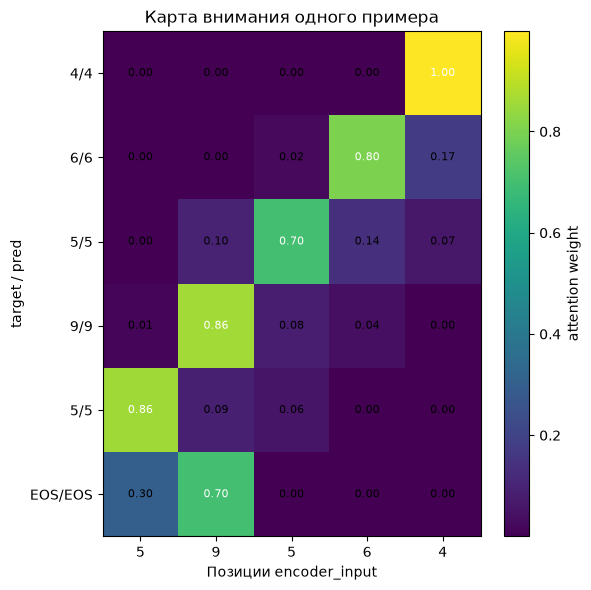

encoder_input : ['5', '9', '5', '6', '4']
decoder_target: ['4', '6', '5', '9', '5', 'EOS']
preds         : ['4', '6', '5', '9', '5', 'EOS']


In [12]:
sample_enc = enc_test[:1]
sample_dec = dec_in_test[:1]
sample_target = dec_tgt_test[:1, :, 0]
sample_probs = model.predict([sample_enc, sample_dec], verbose=0)
sample_preds = sample_probs.argmax(axis=-1)
_, _, _, sample_attention, _ = analysis_model.predict([sample_enc, sample_dec], verbose=0)

enc_valid_len = int(np.count_nonzero(sample_enc[0] != PAD_ID))
tgt_valid_len = int(np.count_nonzero(sample_target[0] != PAD_ID))

score_map = sample_attention[0, :tgt_valid_len, :enc_valid_len]
enc_labels = [decode_token(tok) for tok in sample_enc[0, :enc_valid_len]]
tgt_labels = [decode_token(tok) for tok in sample_target[0, :tgt_valid_len]]
pred_labels = [decode_token(tok) for tok in sample_preds[0, :tgt_valid_len]]
row_labels = [f'{t}/{p}' for t, p in zip(tgt_labels, pred_labels)]

plt.figure(figsize=(max(6, enc_valid_len), max(4, int(0.8 * tgt_valid_len) + 2)))
plt.imshow(score_map, aspect='auto', cmap='viridis')
plt.colorbar(label='attention weight')
plt.xticks(range(enc_valid_len), enc_labels)
plt.yticks(range(tgt_valid_len), row_labels)
plt.xlabel('Позиции encoder_input')
plt.ylabel('target / pred')
plt.title('Карта внимания одного примера')

for i in range(score_map.shape[0]):
    for j in range(score_map.shape[1]):
        value = score_map[i, j]
        color = 'white' if value > 0.5 else 'black'
        plt.text(j, i, f'{value:.2f}', ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()

print('encoder_input :', enc_labels)
print('decoder_target:', tgt_labels)
print('preds         :', pred_labels)


## Как понять, что heatmap адекватна

Порядок чтения карты внимания:
1. Сначала убедитесь, что строки — это decoder-шаги, а столбцы — encoder-позиции.
2. Затем проверьте, что PAD-позиции скрыты и не засоряют картину.
3. И только после этого ищите смысловой паттерн reverse-задачи.

Хорошие признаки:
- фокус смещается по входу, а не застревает в одной колонке;
- структура напоминает антидиагональ;
- heatmap согласуется с метриками, а не противоречит им.


## Что ожидать на практике
- `token_accuracy` обычно растет быстрее `exact_match`.
- По сравнению с plain `GRU seq2seq` модель с attention обычно быстрее исправляет ошибки на длинных последовательностях.
- Для корректной реализации heatmap на reverse-задаче часто показывает движение фокуса примерно по антидиагонали.
- Для корректной реализации ожидается достижение `exact_match >= 0.85`.


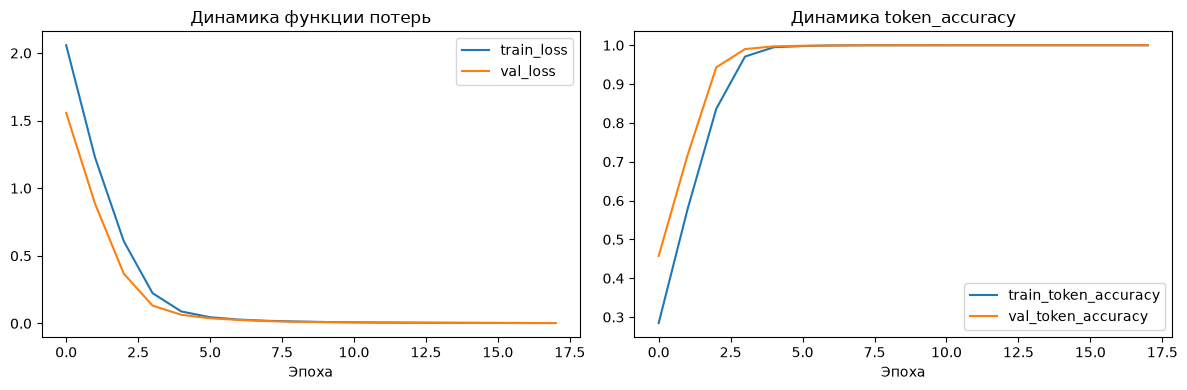

In [13]:
# Визуализация динамики обучения
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Динамика функции потерь')
plt.xlabel('Эпоха')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_token_accuracy')
plt.plot(history.history['val_accuracy'], label='val_token_accuracy')
plt.title('Динамика token_accuracy')
plt.xlabel('Эпоха')
plt.legend()

plt.tight_layout()
plt.show()


## Бонус: сравнение с plain GRU seq2seq
Эта секция необязательна.

Ниже определен baseline без attention на том же датасете. По умолчанию он не обучается, чтобы не удлинять основной проход по ноутбуку.

Если хотите сравнить fixed-context bottleneck с attention на практике, установите `RUN_BASELINE = True`.


In [14]:
def build_plain_seq2seq_model(vocab_size: int = VOCAB_SIZE, emb_dim: int = 32, latent_dim: int = 64):
    encoder_inputs = tf.keras.layers.Input(shape=(ENC_LEN,), name='plain_encoder_inputs')
    enc_emb = tf.keras.layers.Embedding(vocab_size, emb_dim, mask_zero=True, name='plain_enc_embedding')(encoder_inputs)
    encoder_state = tf.keras.layers.GRU(latent_dim, return_state=True, name='plain_enc_gru')(enc_emb)[1]

    decoder_inputs = tf.keras.layers.Input(shape=(DEC_LEN,), name='plain_decoder_inputs')
    dec_emb = tf.keras.layers.Embedding(vocab_size, emb_dim, mask_zero=True, name='plain_dec_embedding')(decoder_inputs)
    decoder_outputs = tf.keras.layers.GRU(
        latent_dim,
        return_sequences=True,
        return_state=True,
        name='plain_dec_gru',
    )(dec_emb, initial_state=encoder_state)[0]

    outputs = tf.keras.layers.Dense(vocab_size, activation='softmax', name='plain_output_head')(decoder_outputs)
    model = tf.keras.Model([encoder_inputs, decoder_inputs], outputs, name='plain_gru_seq2seq')
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


RUN_BASELINE = False

if RUN_BASELINE:
    baseline_model = build_plain_seq2seq_model()
    _ = train_model(baseline_model, enc_train, dec_in_train, dec_tgt_train, epochs=12)
    baseline_metrics = evaluate_model(baseline_model, enc_test, dec_in_test, dec_tgt_test)
    print({
        'attention_token_accuracy': round(metrics['token_accuracy'], 4),
        'attention_exact_match': round(metrics['exact_match'], 4),
        'plain_token_accuracy': round(baseline_metrics['token_accuracy'], 4),
        'plain_exact_match': round(baseline_metrics['exact_match'], 4),
    })
else:
    print('Секция пропущена. Установите RUN_BASELINE = True, чтобы сравнить с plain GRU seq2seq без attention.')


Секция пропущена. Установите RUN_BASELINE = True, чтобы сравнить с plain GRU seq2seq без attention.


## Если не получилось с первого раза

В этой лабораторной полезно чинить проблему слоями:
1. Сначала вернитесь к seq2seq-основе из `01-RNN / ЛР03`.
2. Потом откройте [walkthrough](guides/02_attention_walkthrough.md) только для текущего шага.
3. Если проблема в формах, порядке аргументов или heatmap, откройте [debugging playbook](guides/03_attention_debugging_playbook.md).
4. И только после этого сверяйтесь с solution notebook.


## Если застряли: порядок диагностики

Порядок проверки лучше держать простым: сначала данные, потом формы тензоров, потом модель, и только после этого метрики и визуализации.

1. Сначала проверьте всё, что относится к plain seq2seq: словарь, `PAD/SOS/EOS`, сдвиг и формы входов/таргетов.
2. Затем проверьте, что энкодер действительно возвращает всю последовательность состояний, а не только финальный `state`.
3. Проверьте порядок входов в attention: запросы идут от декодера, а ключи и значения приходят от энкодера.
4. Проверьте форму `attention_scores`: ожидается `(batch, T_out, T_in)`.
5. Если heatmap выглядит хаотично, начните не с визуализации, а с одного ручного примера и проверки базового seq2seq pipeline.


## Чек-лист перед сдачей

- Понимаю, в чём bottleneck plain seq2seq и зачем нужен attention.
- Могу объяснить роли `query`, `key`, `value`, `context` и `attention_scores` на уровне интуиции.
- Проверил формы `encoder_outputs`, `decoder_outputs`, `context` и `attention_scores`.
- Понимаю, как читать heatmap и какой паттерн ожидается на reverse-задаче.
- Могу связать результаты этой ЛР с переходом к следующей теме про Transformer.


## Как использовать решение без самообмана

Полезный режим такой:
1. Сначала собственная попытка.
2. Потом walkthrough для текущего `TODO`.
3. Потом точечная сверка с solution notebook.
4. Потом короткая запись своими словами: что именно было непонятно и почему решение работает.

Если сразу копировать весь блок целиком, можно получить рабочий notebook и пропустить самую важную часть ЛР — понимание decoder shift и строгой метрики `exact_match`.


## Мини-экзамен

Перед тем как считать `02-Attention / ЛР01` закрытой, попробуйте без запуска кода ответить на вопросы:
1. Почему одного `encoder_state` может не хватать для длинной последовательности?
2. Что в этой модели играет роли `query`, `key`, `value`?
3. Почему `Attention([decoder_outputs, encoder_outputs])` чувствителен к порядку аргументов?
4. Зачем нужен `analysis_model`, если уже есть основная модель?
5. Почему `attention_scores` имеют форму `(N, T_out, T_in)`?
6. Как понять по heatmap, что attention работает осмысленно?


## Что дальше

Текущий шаг курса закрывает мостик от RNN к attention.

Следующая большая тема — [`03-Transformer`](../../03-Transformer/lab/README.md):
- там внимание уже не надстройка над RNN;
- появляется `self-attention` и `multi-head attention`;
- важную роль начинают играть positional embeddings и padding-aware encoder blocks.

То есть `02-Attention / ЛР01` — это не отдельная новая нумерация, а финальный шаг линии `01-RNN / ЛР01 -> 01-RNN / ЛР02 -> 01-RNN / ЛР03 -> 02-Attention / ЛР01`, после которого начинается Шаг 5 = `03-Transformer / ЛР01`.


## Вопросы для самопроверки
1. Почему одного `encoder_state` может не хватать для длинной последовательности?
2. Что в этой лабораторной играет роли `query`, `key`, `value`?
3. Чем `cross-attention` отличается от `self-attention`?
4. Почему `Transformer` логично изучать уже после этой лабораторной, а не вместо нее?
5. Почему `token_accuracy` может быть высокой, а `exact_match` заметно ниже?


## Типичные ошибки (симптом -> причина -> исправление)
- `attention_scores` имеет неправильную форму -> перепутаны `query` и `value` -> вызывать `Attention([decoder_outputs, encoder_outputs])`.
- Attention почти бесполезен -> encoder возвращает только один вектор -> включить `return_sequences=True` у `enc_gru`.
- `exact_match` низкий при нормальном `token_accuracy` -> модель ошибается хотя бы в одном шаге многих последовательностей -> проверить `teacher forcing`, конкатенацию `[decoder_outputs; context]` и число эпох.
- Heatmap плохо читается -> PAD-позиции попали в визуализацию -> показывать только значимые строки и столбцы.
